# Imports

In [1]:
from torch.utils.data import DataLoader, random_split
import torch
from data import PermutationDataset
from model import PermutationModel
from train import train_one_epoch, evaluate_model
import matplotlib.pyplot as plt

# Parameters
This includes parameters for what to train on and predict, and also the hyperparameters for training.

In [8]:
n = 5
label_name = "stat3"
layers = [2]

epochs = 1000
train_split, test_split = 0.8, 0.2
learning_rate = 0.001
momentum = 0.9
batch_size = 64

# Initialization
Initialize the data loaders, model, loss function, optimizers.

In [10]:
full_dataset = PermutationDataset(n, label_name)
training_dataset, test_dataset = random_split(full_dataset, [train_split, test_split])
model = PermutationModel(n, layers)
loss_fn = torch.nn.CrossEntropyLoss(full_dataset.class_weights())
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
training_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
losses = []

# Training loop
Train the model for the appropriate number of epochs and then save the model in `models`.

In [11]:
for epoch in range(epochs):
    model.train(True)
    current_loss = train_one_epoch(training_loader, model, loss_fn, optimizer)
    print(f"Epoch {epoch}, Loss {current_loss}")
    losses.append(current_loss)

torch.save(model.state_dict(), f"models/{label_name}_{n}.pt")

Epoch 0, Loss 1.4094220399856567
Epoch 1, Loss 1.4061802625656128
Epoch 2, Loss 1.3832365274429321
Epoch 3, Loss 1.391176462173462
Epoch 4, Loss 1.4556816220283508
Epoch 5, Loss 1.4154765009880066
Epoch 6, Loss 1.3993538618087769
Epoch 7, Loss 1.3936713933944702
Epoch 8, Loss 1.3733997344970703
Epoch 9, Loss 1.3877952098846436
Epoch 10, Loss 1.4373396039009094
Epoch 11, Loss 1.3550638556480408
Epoch 12, Loss 1.401863932609558
Epoch 13, Loss 1.3569055199623108
Epoch 14, Loss 1.3835721611976624
Epoch 15, Loss 1.3717985153198242
Epoch 16, Loss 1.3796457648277283
Epoch 17, Loss 1.3688676357269287
Epoch 18, Loss 1.367652952671051
Epoch 19, Loss 1.3789443969726562
Epoch 20, Loss 1.3411433100700378
Epoch 21, Loss 1.3589494824409485
Epoch 22, Loss 1.3593420386314392
Epoch 23, Loss 1.3458219170570374
Epoch 24, Loss 1.326605498790741
Epoch 25, Loss 1.3452738523483276
Epoch 26, Loss 1.3180590271949768
Epoch 27, Loss 1.344099760055542
Epoch 28, Loss 1.3688188791275024
Epoch 29, Loss 1.359374165534

# Print the loss curve
Visualize the loss curve to ensure that the model is learning correctly. Save the loss curve in `figures/` so that you can refer to them later.

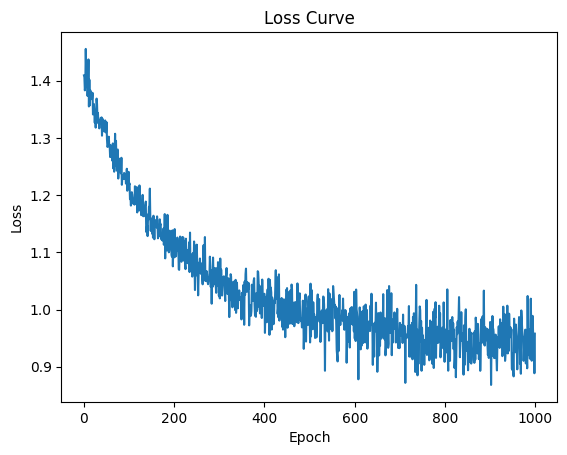

In [12]:
# TODO
# Create a figure and axis
fig, ax = plt.subplots()

# Plot the loss curve
ax.plot(range(len(losses)), losses)

# Add labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Curve')

# Show the plot
plt.show()

# Evaluate the model
Compute the confusion matrix on the train and test dataset and print out the accuracy and plot the confusion matrix.

In [13]:
# TODO
confusion_matrix = evaluate_model(model, test_dataset)
confusion_matrix.print_accuracy()

Accuracy for class 0 = 57.89473684210526%
Accuracy for class 1 = 20.0%
Overall accuracy = 50.0%


# Plot model weights and connections.
Plot the model weights and connections in order to attempt to interpret what the model is learning.

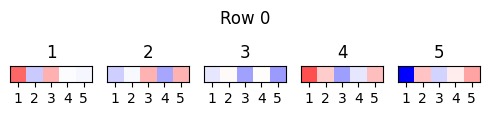

In [ ]:
model.plot_heatmap_feature(0,0)